In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data
data = pd.read_csv('/content/new_country.csv')

# Display data structure
data_info = pd.DataFrame({
    'Total Rows': [data.shape[0]],
    'Total Columns': [data.shape[1]]
})
display(data_info)

# Display first few rows
display(data.head())

# Display column names
column_df = pd.DataFrame({'Column Names': data.columns})
display(column_df)

# Display missing values
missing_values = pd.DataFrame(data.isnull().sum(), columns=['Missing Values'])
display(missing_values)

,Total Rows,Total Columns
0,690,13


,Session primary channel group (Default Channel Group),Country,Sessions,Engaged sessions,Engagement rate,Bounce rate,Average session duration,Average engagement time per session,Events per session,Event count,Session key event rate,Total revenue,Active users
0,Direct,United Kingdom,1107661,693710,0.626284,0.373716,133.351561,42.250308,5.212442,5773619,0,0,235564
1,Email,United Kingdom,771809,492578,0.638212,0.361788,116.578556,44.710095,5.037027,3887623,0,0,149309
2,Organic Search,United Kingdom,573765,424466,0.739791,0.260209,167.683664,78.645522,7.104334,4076218,0,0,140197
3,Referral,United Kingdom,92548,57701,0.623471,0.376529,119.958501,38.541632,4.658404,431126,0,0,17960
4,Unassigned,United Kingdom,47986,1211,0.025237,0.974763,143.193550,69.666528,4.883008,234316,0,0,42862


,Column Names
0,Session primary channel group (Default Channel...
1,Country
2,Sessions
3,Engaged sessions
4,Engagement rate
5,Bounce rate
6,Average session duration
7,Average engagement time per session
8,Events per session
9,Event count


,Missing Values
Session primary channel group (Default Channel Group),0
Country,0
Sessions,0
Engaged sessions,0
Engagement rate,0
Bounce rate,0
Average session duration,0
Average engagement time per session,0
Events per session,0
Event count,0


** Country-Level Summary**

In [ ]:
country_summary = data.groupby('Country')[
    ['Sessions', 'Engaged sessions', 'Engagement rate', 'Bounce rate',
     'Average session duration', 'Average engagement time per session', 'Active users']
].agg({
    'Sessions': 'sum',
    'Engaged sessions': 'sum',
    'Engagement rate': 'mean',
    'Bounce rate': 'mean',
    'Average session duration': 'mean',
    'Average engagement time per session': 'mean',
    'Active users': 'sum'
}).sort_values(by='Sessions', ascending=False)

# Display the summarized data
display(country_summary.head(10))

,Sessions,Engaged sessions,Engagement rate,Bounce rate,Average session duration,Average engagement time per session,Active users
Country,,,,,,,
United Kingdom,2620267,1680728,0.476559,0.523441,85.878648,37.366904,606076
Spain,5124,2537,0.467459,0.532541,59.139651,36.621857,1136
United States,4510,2462,0.592268,0.407732,76.367091,46.226337,1520
Isle of Man,3911,2296,0.570522,0.429478,102.584525,54.743912,941
Guernsey,2717,1843,0.566135,0.433865,160.808172,47.815390,627
Jersey,2578,1836,0.607458,0.392542,143.573209,50.326605,732
France,1944,1043,0.449338,0.550662,66.766839,54.324376,718
Australia,1409,760,0.467029,0.532971,65.103710,49.659205,398
Germany,1197,674,0.534905,0.465095,102.939042,73.781860,397


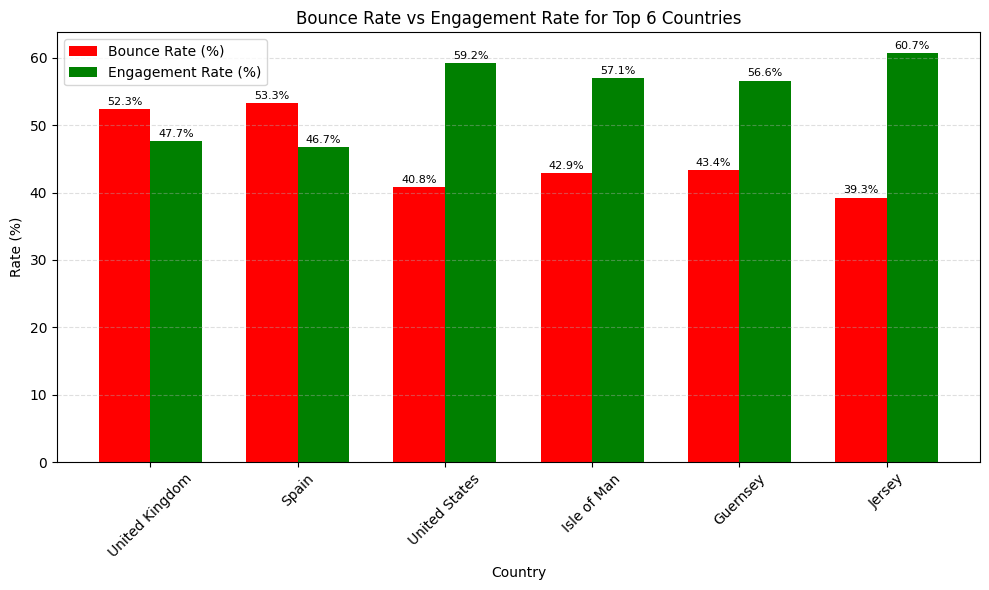

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Select Top 6 Countries by Sessions
top6_countries = country_summary.head(6).reset_index()

# Step 2: Convert rates to % for better readability
top6_countries['Bounce rate (%)'] = top6_countries['Bounce rate'] * 100
top6_countries['Engagement rate (%)'] = top6_countries['Engagement rate'] * 100

# Step 3: Grouped Bar Chart
x = np.arange(len(top6_countries['Country']))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

bar1 = ax.bar(x - bar_width/2, top6_countries['Bounce rate (%)'], width=bar_width, label='Bounce Rate (%)', color='red')
bar2 = ax.bar(x + bar_width/2, top6_countries['Engagement rate (%)'], width=bar_width, label='Engagement Rate (%)', color='green')

# Step 4: Add annotations on bars
for bar in bar1:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0,3), textcoords="offset points", ha='center', fontsize=8)

for bar in bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0,3), textcoords="offset points", ha='center', fontsize=8)

# Step 5: Format the plot
ax.set_xlabel('Country')
ax.set_ylabel('Rate (%)')
ax.set_title('Bounce Rate vs Engagement Rate for Top 6 Countries')
ax.set_xticks(x)
ax.set_xticklabels(top6_countries['Country'], rotation=45)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
